<a href="https://colab.research.google.com/github/ceehrt/Ticket-Classification-using-DeBerta-with-confidence-thresholds/blob/main/Deberta_confidence_thresholds_50_90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Enable GPU in Colab
!nvidia-smi


# Step 2: Install libraries
# Pin Transformers to the version used in your previous environment
!pip install transformers==4.54.0 datasets torch scikit-learn pandas


# Step 3: Verify installations
import torch
import transformers
import datasets
import sklearn
import pandas

print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Datasets version: {datasets.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"Pandas version: {pandas.__version__}")
print(f"CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Sun Sep  6 01:13:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Sep  6 01:13:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             53W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

GPU Available: True
GPU Name: NVIDIA A100-SXM4-80GB
GPU Memory: 85.1 GB


In [ ]:
import torch
import torchvision
import transformers
import tokenizers
import huggingface_hub

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Tokenizers:", tokenizers.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)
print("CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Transformers: 4.54.0
Tokenizers: 0.21.4
Hugging Face Hub: 0.36.2
CUDA: 12.8
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
import json
import numpy as np
import pandas as pd
import re, nltk, spacy, string
import en_core_web_sm
nlp = en_core_web_sm.load()

#Importing libraries required for the case study and to plot charts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

#Importing Regular Expressions for String manipulation
import re

# hide warnings
import warnings
warnings.filterwarnings('ignore')

# set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from pprint import pprint

In [ ]:
root_path = '/content/drive/MyDrive/Colab Notebooks/complaints-2021-05-14_08_16.json'
print("File exists:", os.path.exists(root_path))
print("Path:", root_path)

File exists: False
Path: /content/drive/MyDrive/Colab Notebooks/complaints-2021-05-14_08_16.json


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Now, the file path should be accessible if it's correct
root_path = '/content/drive/MyDrive/Colab Notebooks/complaints-2021-05-14_08_16.json'

# Open the file
f = open(root_path)

# returns JSON object as a dictionary
data = json.load(f)

Mounted at /content/drive


In [ ]:
df=pd.json_normalize(data)
df.head()

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,_source.consumer_disputed,_source.product,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,N/A,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [ ]:
num_rows, num_columns = df.shape

print(f"Rows: {num_rows}, Columns: {num_columns}")

Rows: 78313, Columns: 22


In [ ]:
print(df.columns.tolist())

['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code', '_source.complaint_id', '_source.issue', '_source.date_received', '_source.state', '_source.consumer_disputed', '_source.product', '_source.company_response', '_source.company', '_source.submitted_via', '_source.date_sent_to_company', '_source.company_public_response', '_source.sub_product', '_source.timely', '_source.complaint_what_happened', '_source.sub_issue', '_source.consumer_consent_provided']


In [ ]:
print(df.columns)

Index(['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.company_public_response',
       '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.sub_issue',
       '_source.consumer_consent_provided'],
      dtype='object')


In [ ]:
df = df[['_source.complaint_what_happened','_source.product','_source.sub_product','_source.issue','_source.sub_issue',]]
df.head()

,_source.complaint_what_happened,_source.product,_source.sub_product,_source.issue,_source.sub_issue
0,,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I apprec...,Debt collection,Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage,Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Charged too much interest


In [ ]:
df = df.rename(columns={'_source.complaint_what_happened': 'complaint_text', '_source.product': 'category','_source.sub_product': 'sub_category'})
df.head()

,complaint_text,category,sub_category,_source.issue,_source.sub_issue
0,,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I apprec...,Debt collection,Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Credit card or prepaid card,General-purpose credit card or charge card,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage,Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Charged too much interest


In [ ]:
df['category'] = df['category'] + '+' + df['sub_category']
df = df.drop(['sub_category'],axis= 1)
df.head()

,complaint_text,category,_source.issue,_source.sub_issue
0,,Debt collection+Credit card debt,Attempts to collect debt not owed,Debt is not yours
1,Good morning my name is XXXX XXXX and I apprec...,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Credit card or prepaid card+General-purpose cr...,"Other features, terms, or problems",Problem with rewards from credit card
3,,Mortgage+Conventional home mortgage,Trouble during payment process,None
4,,Credit card or prepaid card+General-purpose cr...,Fees or interest,Charged too much interest


In [ ]:
df.complaint_text.isnull().sum()

np.int64(0)

In [ ]:
len(df[df['complaint_text']==''])

57241

In [ ]:
df[df['complaint_text']==''] = np.nan
df.complaint_text.isnull().sum()

np.int64(57241)

In [ ]:
#Remove all rows where complaints column is nan
# Lets drop all the rows where complaint_text is null
df = df[~df['complaint_text'].isnull()]
df.complaint_text.isnull().sum()

np.int64(0)

In [ ]:
df.head()

,complaint_text,category,_source.issue,_source.sub_issue
1,Good morning my name is XXXX XXXX and I apprec...,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Credit card or prepaid card+General-purpose cr...,"Other features, terms, or problems",Problem with rewards from credit card
10,Chase Card was reported on XX/XX/2019. However...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else
11,"On XX/XX/2018, while trying to book a XXXX XX...","Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else
14,my grand son give me check for {$1600.00} i de...,Checking or savings account+Checking account,Managing an account,Funds not handled or disbursed as instructed


In [ ]:
df["_source.issue"].isnull().sum()

np.int64(0)

In [ ]:
df["_source.sub_issue"].isnull().sum()

np.int64(8176)

In [ ]:
#df['complaint_text'] = df['_source.issue'] + '+' + df['_source.sub_issue'] + '+' + df['complaint_text']
#df = df.drop(['sub_category'],axis= 1)
df['issue'] = df['_source.issue']
df['sub_issue'] = df['_source.sub_issue']
df['complaint_text'] = df['issue'] + ' + ' + df['sub_issue'] + ' + ' + df['complaint_text']

df.head()

,complaint_text,category,_source.issue,_source.sub_issue,issue,sub_issue
1,Written notification about debt + Didn't recei...,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt,Written notification about debt,Didn't receive enough information to verify debt
2,"Other features, terms, or problems + Problem w...",Credit card or prepaid card+General-purpose cr...,"Other features, terms, or problems",Problem with rewards from credit card,"Other features, terms, or problems",Problem with rewards from credit card
10,Incorrect information on your report + Informa...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else,Incorrect information on your report,Information belongs to someone else
11,Incorrect information on your report + Informa...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else,Incorrect information on your report,Information belongs to someone else
14,Managing an account + Funds not handled or dis...,Checking or savings account+Checking account,Managing an account,Funds not handled or disbursed as instructed,Managing an account,Funds not handled or disbursed as instructed


In [ ]:
df = df.drop(['_source.issue'],axis= 1)
df = df.drop(['_source.sub_issue'],axis= 1)

In [ ]:
print(df.columns)

Index(['complaint_text', 'category', 'issue', 'sub_issue'], dtype='object')


In [ ]:
df.head()

,complaint_text,category,issue,sub_issue
1,Written notification about debt + Didn't recei...,Debt collection+Credit card debt,Written notification about debt,Didn't receive enough information to verify debt
2,"Other features, terms, or problems + Problem w...",Credit card or prepaid card+General-purpose cr...,"Other features, terms, or problems",Problem with rewards from credit card
10,Incorrect information on your report + Informa...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else
11,Incorrect information on your report + Informa...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else
14,Managing an account + Funds not handled or dis...,Checking or savings account+Checking account,Managing an account,Funds not handled or disbursed as instructed


In [ ]:
len(df[df['complaint_text']==''])

0

In [ ]:
df["issue"].isnull().sum()

np.int64(0)

In [ ]:
df["sub_issue"].isnull().sum()

np.int64(8176)

In [ ]:
df = df[~df['sub_issue'].isnull()]

In [ ]:
num_records = df.shape[0]
print(f"Number of records: {num_records}")

Number of records: 12896


In [ ]:
df['cleaned_text'] = df['complaint_text']

In [ ]:
import re
import string
import pandas as pd
from typing import Union

def clean_text_for_bert(text: Union[str, float]) -> str:
    """
    Optimized text cleaner that removes:
    - Time patterns (10mins, 10minutes)
    - All x/x+ patterns (xxxx, xxxxx)
    - Standalone numbers (10, 42)
    - While preserving meaningful numbers (v2, 3x)
    """
    if pd.isna(text):
        return ""
    text = str(text).lower()

    # Remove time patterns (10mins, 10 minutes etc.)
    text = re.sub(r'\b\d+\s*(mins|minutes|hours|hrs|hr)\b', '', text)

    # Remove all x+ patterns
    text = re.sub(r'\bx+\b', '', text, flags=re.IGNORECASE)

    # Remove standalone numbers but preserve version/quantities
    text = re.sub(r'\b(?<![a-z#])\d+\b', '', text)  # Standalone numbers
    text = re.sub(r'\b\d+[a-z]+\b', '', text)  # Catch remaining number+word combos

    # Original PII removal and cleaning logic
    text = re.sub(r'(ticket|case|ref)\s*[:#-]?\s*\w*\d+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[[^\[\]]*\]|\{[^{}]*\}|<[^<>]*>', '', text)
    text = re.sub(r'\b(?:\d[ -]*?){13,19}\b', '[CREDIT_CARD]', text)
    text = re.sub(r'\b\d{3}[ -]?\d{3}[ -]?\d{4}\b', '[PHONE]', text)
    text = re.sub(r'\b(?:\w+[.-])*\w+@\w+[.-]\w+\b', '[EMAIL]', text)

    # Final cleanup
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    punct_to_keep = '!?'
    punct_to_remove = ''.join([c for c in string.punctuation if c not in punct_to_keep])
    text = text.translate(str.maketrans('', '', punct_to_remove))
    text = ' '.join(text.split())

    return text.strip()

# Apply to DataFrame
if 'cleaned_text' in df.columns:
    df['cleaned_text'] = df['cleaned_text'].apply(clean_text_for_bert)

In [ ]:
pd.set_option('display.max_colwidth', None)
df['cleaned_text'].head()

,cleaned_text
1,written notification about debt didnt receive enough information to verify debt good morning my name is and i appreciate it if you could help me put a stop to chase bank cardmember services in i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt i have a right to know this information as a consumer chase account thanks in advance for your help
2,other features terms or problems problem with rewards from credit card i upgraded my card in and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account changed my anniversary date from to without my consent! has the recording of the agent who was misled me
10,incorrect information on your report information belongs to someone else chase card was reported on however fraudulent application have been submitted my identity without my consent to fraudulently obtain services do not extend credit without verifying the identity of the applicant
11,incorrect information on your report information belongs to someone else on while trying to book a ticket i came across an offer for to be applied towards the ticket if i applied for a rewards card i put in my information for the offer and within less than a minute was notified via the screen that a decision could not be made i immediately contacted and was referred to chase bank i then immediately contacted chase bank within no more than of getting the notification on the screen and i was told by the chase representative i spoke with that my application was denied but she could not state why i asked for more information about the offer and she explained that even if i had been approved the credit offer only gets applied after the first account statement and could not be used to purchase the ticket i then explicitly told her i was glad i got denied and i was absolutely no longer interested in the account i asked that the application be withdrawn and the representative obliged this all happened no later than after putting in the application on notwithstanding my explicit request not to proceed with the application and contrary to what i was told by the chase representative chase did in fact go ahead to open a credit account in my name on this is now being reported in my credit report and chase has refused to correct this information on my credit report even though they went ahead to process an application which i did not consent to and out of their error
14,managing an account funds not handled or disbursed as instructed my grand son give me check for i deposit it into my chase account after fund clear my chase bank closed my account never paid me my money they said they need to speek with my grand son check was clear money was taking by my chase bank refuse to pay me my money my grand son called chase times they told him i should call not him to verify the check owner he is out the country most the time date happen check number claim number is with chase


Using GPU: NVIDIA A100-SXM4-80GB


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/874M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/874M [00:00<?, ?B/s]


📏 Token Length Statistics:
Min: 11, Max: 4773, Avg: 246.79
90th percentile: 491.0
95th percentile: 667.0


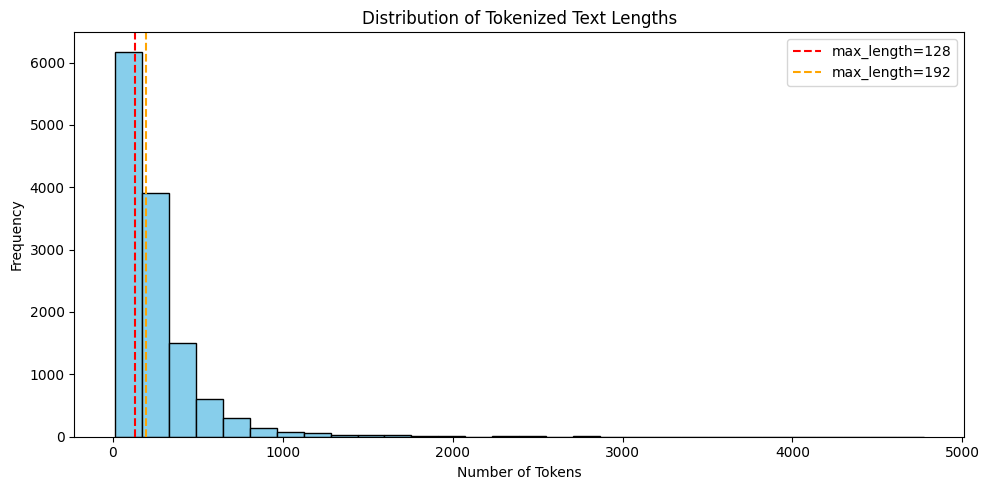


📏 Token Length Statistics:
Min: 11, Max: 4773, Avg: 246.79
90th percentile: 491.00
95th percentile: 667.00


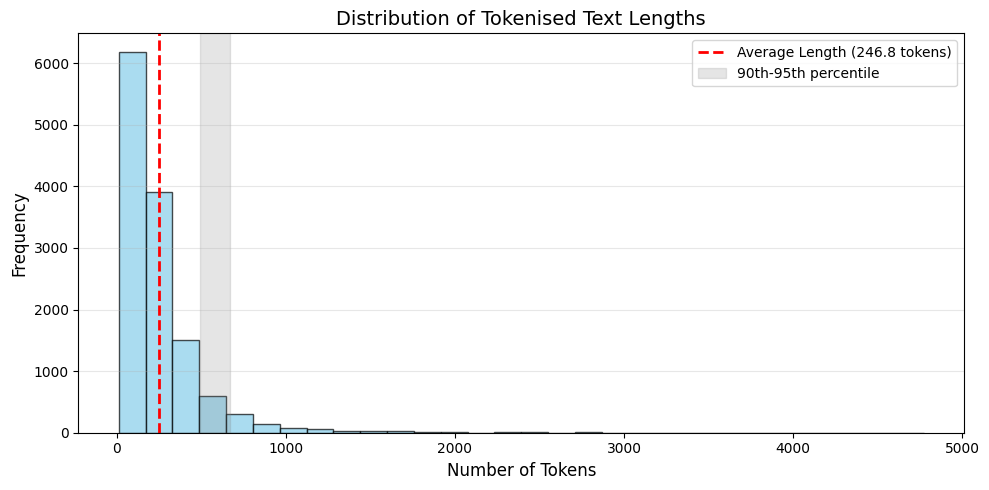


⚙️ Generating embeddings...

🔍 Running clustering...
Using GPU-accelerated cuML KMeans


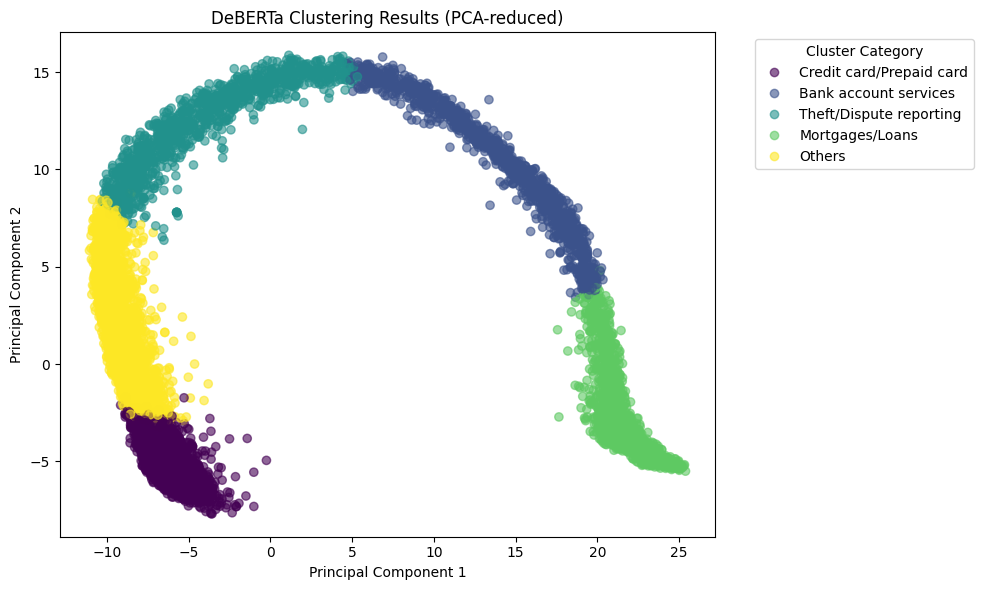


✅ Clustering completed successfully!


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

# 1. GPU Setup with validation
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()  # Clear memory
else:
    device = torch.device("cpu")
    print("Using CPU")

# 2. Load DeBERTa with GPU optimization
model_name = "microsoft/deberta-v3-large"
try:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
except Exception as e:
    raise RuntimeError(f"Model loading failed: {str(e)}")

# 2.1 Token length analysis
texts = df['cleaned_text'].astype(str).tolist()
token_lengths = [len(tokenizer.encode(text, truncation=False)) for text in texts]

print("\n📏 Token Length Statistics:")
print(f"Min: {np.min(token_lengths)}, Max: {np.max(token_lengths)}, Avg: {np.mean(token_lengths):.2f}")
print(f"90th percentile: {np.percentile(token_lengths, 90)}")
print(f"95th percentile: {np.percentile(token_lengths, 95)}")

plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=128, color='red', linestyle='--', label='max_length=128')
plt.axvline(x=192, color='orange', linestyle='--', label='max_length=192')
plt.title("Distribution of Tokenized Text Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# 2.1 Token length analysis
texts = df['cleaned_text'].astype(str).tolist()
token_lengths = [len(tokenizer.encode(text, truncation=False)) for text in texts]

# Calculate statistics
avg_length = np.mean(token_lengths)
percentile_90 = np.percentile(token_lengths, 90)
percentile_95 = np.percentile(token_lengths, 95)

print("\n📏 Token Length Statistics:")
print(f"Min: {np.min(token_lengths)}, Max: {np.max(token_lengths)}, Avg: {avg_length:.2f}")
print(f"90th percentile: {percentile_90:.2f}")
print(f"95th percentile: {percentile_95:.2f}")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=avg_length, color='red', linestyle='--', linewidth=2,
            label=f'Average Length ({avg_length:.1f} tokens)')

# Add shaded region for percentiles
plt.axvspan(percentile_90, percentile_95, color='gray', alpha=0.2,
           label='90th-95th percentile')

plt.title("Distribution of Tokenised Text Lengths", fontsize=14)
plt.xlabel("Number of Tokens", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Memory-efficient embedding generation using mean pooling
def generate_embeddings(texts, batch_size=4, max_length=384):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        try:
            with torch.no_grad():
                inputs = tokenizer(
                    batch,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt"
                ).to(device)

                outputs = model(**inputs)
                mean_embedding = outputs.last_hidden_state.mean(dim=1)  # Mean Pooling
                embeddings.append(mean_embedding.cpu())  # Correct tensor

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Batch {i//batch_size} failed - reducing batch size")
                return generate_embeddings(texts, batch_size=batch_size//2, max_length=max_length)
            raise

    return torch.cat(embeddings).numpy()

# 4. GPU-optimized clustering
def cluster_with_gpu(embeddings, n_clusters=5):
    # Normalize on CPU (faster for this operation)
    embeddings = Normalizer(norm='l2').fit_transform(embeddings)

    # PCA for dimensionality reduction
    pca = PCA(n_components=min(256, embeddings.shape[1]-1))
    reduced = pca.fit_transform(embeddings)

    # K-means with GPU acceleration (via cuML if available)
    try:
        from cuml.cluster import KMeans  # RAPIDS cuML
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        print("Using GPU-accelerated cuML KMeans")
    except ImportError:
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
        print("Using scikit-learn CPU KMeans")

    clusters = kmeans.fit_predict(reduced)
    return clusters, kmeans

# 5. Execute pipeline (corrected version)
try:
    # Generate embeddings first
    print("\n⚙️ Generating embeddings...")
    embeddings = generate_embeddings(texts, batch_size=8, max_length=384)

    # Perform clustering
    print("\n🔍 Running clustering...")
    clusters, kmeans = cluster_with_gpu(embeddings, n_clusters=5)

    # Reduce dimensions for visualization
    pca_vis = PCA(n_components=2)
    embeddings_2d = pca_vis.fit_transform(embeddings)

    # Visualize
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=clusters,
        cmap='viridis',
        alpha=0.6
    )

    # Define your cluster mapping
    cluster_mapping = {
        0: "Credit card/Prepaid card",
        1: "Bank account services",
        2: "Theft/Dispute reporting",
        3: "Mortgages/Loans",
        4: "Others"
    }

    # Create legend with mapped labels
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    unique_clusters = np.unique(clusters)
    legend_labels = [cluster_mapping.get(i, f"Cluster {i}") for i in unique_clusters]

    plt.legend(handles, legend_labels, title="Cluster Category", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("DeBERTa Clustering Results (PCA-reduced)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()

    # Add cluster results to your DataFrame
    df['cluster'] = clusters
    print("\n✅ Clustering completed successfully!")

except Exception as e:
    print(f"\n❌ Pipeline failed: {str(e)}")
    if torch.cuda.is_available():
        print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f}GB")

In [ ]:
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Memory allocated: 1.75 GB


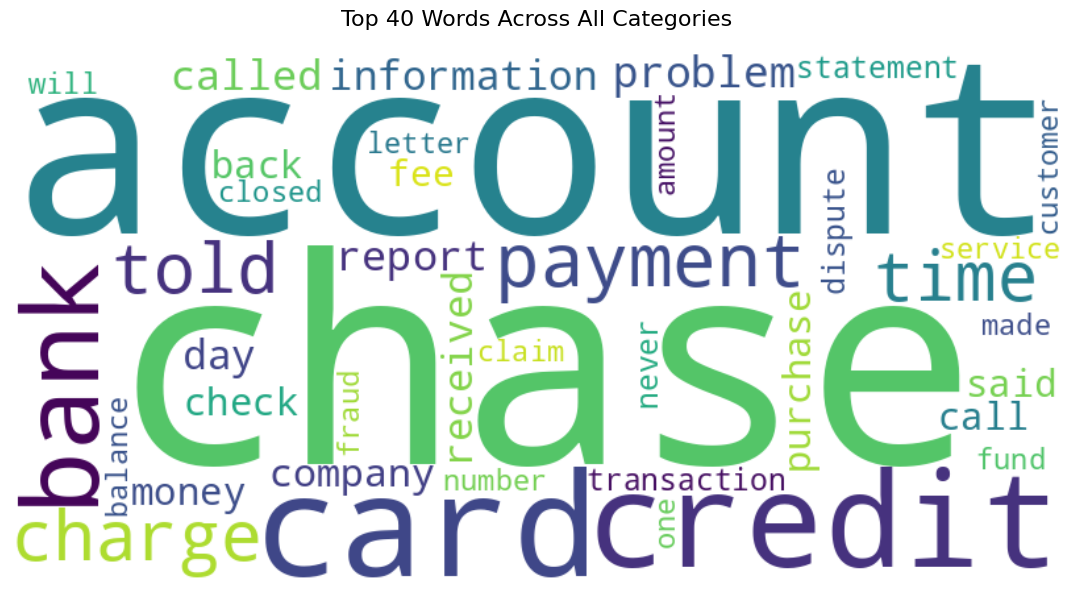

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Aggregate text from ALL clusters
all_text = " ".join(df['cleaned_text'])  # Combine all cleaned text

# Generate word cloud with exactly 40 words
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=40,  # Show exactly 40 words
    collocations=False,  # Don't consider word pairs
    prefer_horizontal=0.8,  # Prefer horizontal words
    min_font_size=8  # Minimum font size
).generate(all_text)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Top 40 Words Across All Categories", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

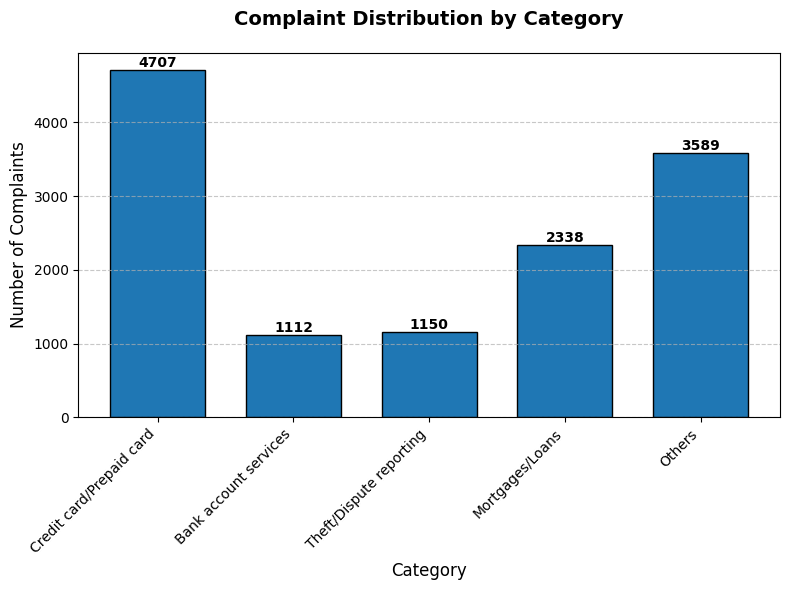

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Category mapping
cluster_mapping = {
    0: "Credit card/Prepaid card",
    1: "Bank account services",
    2: "Theft/Dispute reporting",
    3: "Mortgages/Loans",
    4: "Others"
}

# Get value counts and sort
value_counts = df['cluster'].value_counts().sort_index()

# Define a single color for all bars
single_color = '#1f77b4'  # Blue

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(value_counts)),
               value_counts.values,
               color=single_color,
               edgecolor='black',
               width=0.7)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Customize plot
plt.title('Complaint Distribution by Category', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)

plt.xticks(range(len(value_counts)),
           [cluster_mapping[i] for i in value_counts.index],
           rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


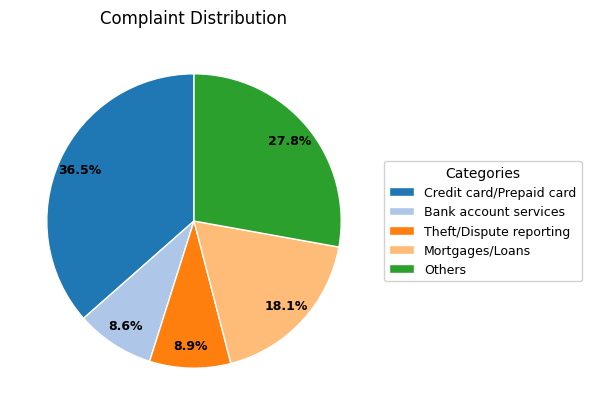

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare the data
value_counts = df['cluster'].value_counts().sort_index()
categories = [cluster_mapping[i] for i in value_counts.index]  # Get category names
sizes = value_counts.values
total = sum(sizes)

# 2. Create the clean pie chart
plt.figure(figsize=(6, 6))

# Create the pie with percentage labels only
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,  # Remove category labels from wedges
    colors=plt.cm.tab20.colors[:len(categories)],  # Distinct colors
    autopct=lambda p: f'{p:.1f}%',  # Show all percentages
    pctdistance=0.85,  # Move percentages inward
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 9}
)

# 3. Style the percentage labels
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# 4. Add elegant legend
legend_labels = [f'{cat}' for cat in categories]  # No counts in legend
plt.legend(wedges, legend_labels,
           title="Categories",
           loc="center left",
           bbox_to_anchor=(1, 0.5),
           fontsize=9,
           framealpha=0.9)

# 5. Add minimal title
plt.title('Complaint Distribution', fontsize=12, pad=10)
plt.tight_layout()
plt.show()


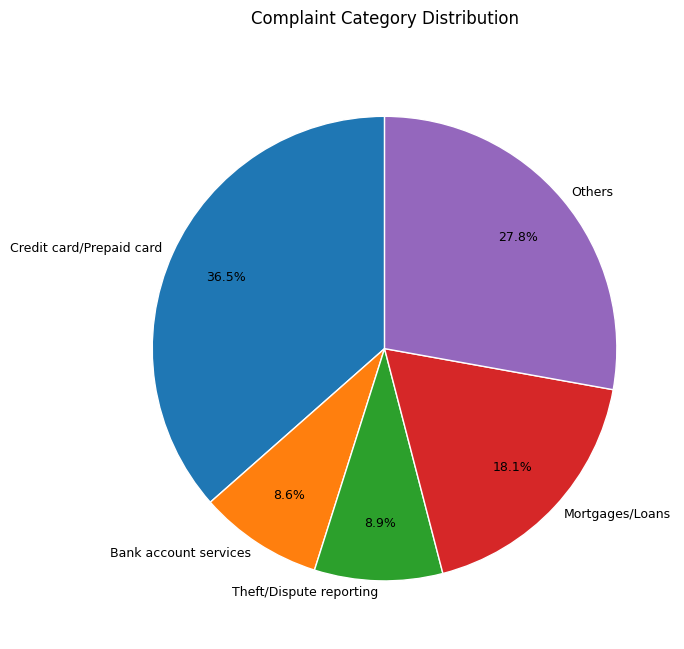

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
value_counts = df['cluster'].value_counts().sort_index()
categories = [cluster_mapping[i] for i in value_counts.index]
sizes = value_counts.values

# Create medium-sized pie chart (7x7 inches)
plt.figure(figsize=(7, 7))

# Create the pie chart with optimized layout
patches, texts, autotexts = plt.pie(
    sizes,
    labels=categories,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.tab10.colors[:len(categories)],  # Uses first 10 distinct colors
    textprops={'fontsize': 10},
    pctdistance=0.75,  # Bring percentages closer to center
    labeldistance=1.05,  # Slightly outward labels
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

# Improve label readability
for text in texts:
    text.set_fontsize(9)  # Slightly smaller category labels

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('black')

# Add compact title
plt.title('Complaint Category Distribution\n', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)


Index(['complaint_text', 'category', 'issue', 'sub_issue', 'cleaned_text',
       'cluster'],
      dtype='object')


In [ ]:
# ============================================================
# Cell 1: Imports and Setup
# ============================================================

import time
import random
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


# Reproducibility
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA: 12.8


In [ ]:
# ============================================================
# Cell 2: Configuration
# ============================================================

MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LEN = 384
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 2e-5

label_map = {
    0: "Credit card/Prepaid card",
    1: "Bank account services",
    2: "Theft/Dispute reporting",
    3: "Mortgages/Loans",
    4: "Others"
}

print("Model:", MODEL_NAME)
print("Classes:", len(label_map))

Model: microsoft/deberta-v3-base
Classes: 5


In [ ]:
# ============================================================
# Cell 3: PyTorch Dataset
# ============================================================

class TicketDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# OK for only 50% confident threshold
# ============================================================
# Cell 4: Evaluation Function + Confidence Threshold
# ============================================================

def evaluate_model(
    model,
    dataloader,
    label_map,
    device,
    mode="Evaluation",
    return_predictions=False
):

    model.eval()

    preds = []
    true_labels = []
    logits_list = []
    confidence_scores = []

    with torch.no_grad():

        for batch in dataloader:

            inputs = {
                k: v.to(device)
                for k, v in batch.items()
                if k != "labels"
            }

            labels = batch["labels"].to(device)

            outputs = model(**inputs)

            logits = outputs.logits

            # Convert logits to probabilities
            probabilities = torch.softmax(
                logits,
                dim=-1
            )

            # Get predicted class and confidence score
            confidence, pred = torch.max(
                probabilities,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            true_labels.extend(
                labels.cpu().numpy()
            )

            logits_list.extend(
                logits.cpu().numpy()
            )

            confidence_scores.extend(
                confidence.cpu().numpy()
            )

    # ========================================================
    # Metrics
    # ========================================================

    acc = accuracy_score(
        true_labels,
        preds
    )

    precision = precision_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    probabilities = torch.softmax(
        torch.tensor(
            np.array(logits_list)
        ),
        dim=-1
    ).numpy()

    roc_auc = roc_auc_score(
        true_labels,
        probabilities,
        multi_class="ovr"
    )

    print(f"\n{mode} Metrics:")

    print(
        f"Accuracy: {acc:.4f} | "
        f"Precision: {precision:.4f} | "
        f"F1: {f1:.4f} | "
        f"ROC AUC: {roc_auc:.4f}"
    )

    print(
        classification_report(
            true_labels,
            preds,
            target_names=label_map.values(),
            digits=4,
            zero_division=0
        )
    )

    # ========================================================
    # Confidence Threshold Analysis
    # ========================================================

    confidence_array = np.array(
        confidence_scores
    )

    total_tickets = len(
        confidence_array
    )

    # Below 50%
    below_50 = np.sum(
        confidence_array < 0.50
    )

    # 50% or above
    over_50 = np.sum(
        confidence_array >= 0.50
    )

    # Percentages
    below_50_percentage = (
        below_50 /
        total_tickets *
        100
    )

    over_50_percentage = (
        over_50 /
        total_tickets *
        100
    )

    print(
        f"\n{mode} Confidence Threshold Summary:"
    )

    print(
        f"Total tickets: "
        f"{total_tickets}"
    )

    print(
        f"Confidence < 50%: "
        f"{below_50} "
        f"({below_50_percentage:.2f}%)"
    )

    print(
        f"Confidence >= 50%: "
        f"{over_50} "
        f"({over_50_percentage:.2f}%)"
    )

    # ========================================================
    # Confusion Matrix
    # ========================================================

    plt.figure(
        figsize=(10, 7)
    )

    sns.heatmap(
        confusion_matrix(
            true_labels,
            preds
        ),
        annot=True,
        fmt="d",
        xticklabels=label_map.values(),
        yticklabels=label_map.values(),
        cmap="Blues"
    )

    plt.title(
        f"{mode} Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()

    # ========================================================
    # Results
    # ========================================================

    results = {
        "accuracy": acc,
        "precision": precision,
        "f1": f1,
        "roc_auc": roc_auc,

        # Confidence threshold results
        "total_tickets": total_tickets,
        "confidence_below_50": below_50,
        "confidence_over_50": over_50,
        "percentage_below_50":
            below_50_percentage,
        "percentage_over_50":
            over_50_percentage
    }

    # ========================================================
    # Return detailed predictions if required
    # ========================================================

    if return_predictions:

        results["predictions"] = np.array(
            preds
        )

        results["true_labels"] = np.array(
            true_labels
        )

        results["confidence"] = (
            confidence_array
        )

        results["probabilities"] = (
            probabilities
        )

    return results

In [ ]:
# ============================================================
# Cell 4: Evaluation Function + Confidence Threshold Analysis
# ============================================================

def evaluate_model(
    model,
    dataloader,
    label_map,
    device,
    mode="Evaluation",
    return_predictions=False
):

    model.eval()

    preds = []
    true_labels = []
    logits_list = []
    confidence_scores = []

    # ========================================================
    # Prediction
    # ========================================================

    with torch.no_grad():

        for batch in dataloader:

            inputs = {
                k: v.to(device)
                for k, v in batch.items()
                if k != "labels"
            }

            labels = batch["labels"].to(device)

            outputs = model(**inputs)

            logits = outputs.logits

            # Convert logits to probabilities
            probabilities_batch = torch.softmax(
                logits,
                dim=-1
            )

            # Highest probability = confidence score
            confidence, pred = torch.max(
                probabilities_batch,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            true_labels.extend(
                labels.cpu().numpy()
            )

            logits_list.extend(
                logits.cpu().numpy()
            )

            confidence_scores.extend(
                confidence.cpu().numpy()
            )

    # Convert to NumPy arrays
    preds = np.array(preds)
    true_labels = np.array(true_labels)
    confidence_array = np.array(confidence_scores)

    # ========================================================
    # Standard Metrics
    # ========================================================

    acc = accuracy_score(
        true_labels,
        preds
    )

    precision = precision_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        true_labels,
        preds,
        average="weighted",
        zero_division=0
    )

    probabilities = torch.softmax(
        torch.tensor(
            np.array(logits_list)
        ),
        dim=-1
    ).numpy()

    roc_auc = roc_auc_score(
        true_labels,
        probabilities,
        multi_class="ovr"
    )

    print(f"\n{mode} Metrics:")

    print(
        f"Accuracy: {acc:.4f} | "
        f"Precision: {precision:.4f} | "
        f"F1: {f1:.4f} | "
        f"ROC AUC: {roc_auc:.4f}"
    )

    print(
        classification_report(
            true_labels,
            preds,
            target_names=label_map.values(),
            digits=4,
            zero_division=0
        )
    )

    # ========================================================
    # Overall Error Information
    # ========================================================

    total_tickets = len(
        true_labels
    )

    incorrect_mask = (
        preds != true_labels
    )

    correct_mask = (
        preds == true_labels
    )

    total_errors = np.sum(
        incorrect_mask
    )

    total_correct = np.sum(
        correct_mask
    )

    print(
        f"\n{mode} Prediction Summary:"
    )

    print(
        f"Total tickets: {total_tickets}"
    )

    print(
        f"Correct predictions: "
        f"{total_correct}"
    )

    print(
        f"Incorrect predictions: "
        f"{total_errors}"
    )

    # ========================================================
    # Confidence Threshold Analysis
    # ========================================================

    thresholds = [
        0.50,
        0.60,
        0.70,
        0.80,
        0.90
    ]

    threshold_results = {}

    print(
        f"\n{mode} Confidence Threshold Analysis:"
    )

    print(
        "-" * 100
    )

    print(
        f"{'Threshold':<12}"
        f"{'Below':<12}"
        f"{'Above':<12}"
        f"{'Correct Below':<18}"
        f"{'Wrong Below':<16}"
        f"{'% Errors Captured':<18}"
    )

    print(
        "-" * 100
    )

    for threshold in thresholds:

        # Tickets below threshold
        below_mask = (
            confidence_array < threshold
        )

        # Tickets at or above threshold
        above_mask = (
            confidence_array >= threshold
        )

        below_count = np.sum(
            below_mask
        )

        above_count = np.sum(
            above_mask
        )

        # Correct predictions below threshold
        correct_below = np.sum(
            below_mask &
            correct_mask
        )

        # Wrong predictions below threshold
        wrong_below = np.sum(
            below_mask &
            incorrect_mask
        )

        # Percentage of all DeBERTa errors captured
        if total_errors > 0:

            error_capture_rate = (
                wrong_below /
                total_errors *
                100
            )

        else:
            error_capture_rate = 0.0

        # Percentage of tickets below threshold
        below_percentage = (
            below_count /
            total_tickets *
            100
        )

        # Percentage of tickets above threshold
        above_percentage = (
            above_count /
            total_tickets *
            100
        )

        threshold_results[
            threshold
        ] = {

            "below": below_count,

            "above": above_count,

            "below_percentage":
                below_percentage,

            "above_percentage":
                above_percentage,

            "correct_below":
                correct_below,

            "wrong_below":
                wrong_below,

            "error_capture_rate":
                error_capture_rate
        }

        print(
            f"{int(threshold * 100)}%{'':<9}"
            f"{below_count:<12}"
            f"{above_count:<12}"
            f"{correct_below:<18}"
            f"{wrong_below:<16}"
            f"{error_capture_rate:.2f}%"
        )

    print(
        "-" * 100
    )

    # ========================================================
    # Confusion Matrix
    # ========================================================

    plt.figure(
        figsize=(10, 7)
    )

    sns.heatmap(
        confusion_matrix(
            true_labels,
            preds
        ),
        annot=True,
        fmt="d",
        xticklabels=label_map.values(),
        yticklabels=label_map.values(),
        cmap="Blues"
    )

    plt.title(
        f"{mode} Confusion Matrix"
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "Actual"
    )

    plt.show()

    # ========================================================
    # Results
    # ========================================================

    results = {

        "accuracy": acc,

        "precision": precision,

        "f1": f1,

        "roc_auc": roc_auc,

        "total_tickets":
            total_tickets,

        "total_correct":
            total_correct,

        "total_errors":
            total_errors,

        "threshold_results":
            threshold_results
    }

    # ========================================================
    # Return detailed predictions if required
    # ========================================================

    if return_predictions:

        results["predictions"] = (
            preds
        )

        results["true_labels"] = (
            true_labels
        )

        results["confidence"] = (
            confidence_array
        )

        results["probabilities"] = (
            probabilities
        )

    return results

In [ ]:
# ============================================================
# Cell 5: Train/Test Split
# ============================================================

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["cluster"],
    random_state=SEED
)

texts_train = (
    df_train["cleaned_text"]
    .astype(str)
    .values
)

labels_train = (
    df_train["cluster"]
    .values
)

texts_test = (
    df_test["cleaned_text"]
    .astype(str)
    .values
)

labels_test = (
    df_test["cluster"]
    .values
)

print("Training samples:", len(texts_train))
print("Testing samples:", len(texts_test))

Training samples: 10316
Testing samples: 2580


In [ ]:
# ============================================================
# Cell 6: Tokenizer and Test Data
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

test_encodings = tokenizer(
    list(texts_test),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_dataset = TicketDataset(
    test_encodings,
    labels_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test DataLoader ready.")

Test DataLoader ready.


In [ ]:
# ============================================================
# Cell 7: Training Function
# ============================================================

def train_model(
    texts_train,
    labels_train,
    test_loader,
    tokenizer,
    label_map,
    model_name,
    max_len=384,
    epochs=3,
    batch_size=8,
    learning_rate=2e-5
):

    print(
        f"\n========== Training: {model_name} =========="
    )

    total_start_time = time.time()

    # ----------------------------------------
    # 5-Fold Cross Validation
    # ----------------------------------------

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    fold_results = []
    fold_times = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(
            texts_train,
            labels_train
        )
    ):

        fold_start_time = time.time()

        print(
            f"\n=== Fold {fold + 1}/5 ==="
        )

        train_texts = texts_train[
            train_idx
        ]

        train_labels = labels_train[
            train_idx
        ]

        val_texts = texts_train[
            val_idx
        ]

        val_labels = labels_train[
            val_idx
        ]

        # -----------------------------------
        # Encode training data
        # -----------------------------------

        train_encodings = tokenizer(
            list(train_texts),
            truncation=True,
            padding=True,
            max_length=max_len
        )

        train_dataset = TicketDataset(
            train_encodings,
            train_labels
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True
        )

        # -----------------------------------
        # Load model
        # -----------------------------------

        model = (
            AutoModelForSequenceClassification
            .from_pretrained(
                model_name,
                num_labels=len(label_map)
            )
            .to(device)
        )

        optimizer = AdamW(
            model.parameters(),
            lr=learning_rate
        )

        total_steps = (
            len(train_loader)
            * epochs
        )

        scheduler = (
            get_linear_schedule_with_warmup(
                optimizer,
                num_warmup_steps=0,
                num_training_steps=total_steps
            )
        )

        # -----------------------------------
        # Training Loop
        # -----------------------------------

        for epoch in range(epochs):

            epoch_start_time = time.time()

            print(
                f"\nEpoch {epoch + 1}/{epochs}"
            )

            model.train()

            total_loss = 0

            for batch in tqdm(
                train_loader
            ):

                optimizer.zero_grad()

                inputs = {
                    k: v.to(device)
                    for k, v
                    in batch.items()
                }

                outputs = model(
                    **inputs
                )

                loss = outputs.loss

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0
                )

                optimizer.step()

                scheduler.step()

                total_loss += (
                    loss.item()
                )

            average_loss = (
                total_loss /
                len(train_loader)
            )

            epoch_time = (
                time.time()
                - epoch_start_time
            )

            print(
                f"Average Loss: "
                f"{average_loss:.4f}"
            )

            print(
                f"Epoch completed in "
                f"{epoch_time:.2f} seconds"
            )

        # -----------------------------------
        # Fold Time
        # -----------------------------------

        fold_time = (
            time.time()
            - fold_start_time
        )

        fold_times.append(
            fold_time
        )

        print(
            f"\nFold {fold + 1} "
            f"completed in "
            f"{fold_time / 60:.2f} minutes"
        )

        # -----------------------------------
        # Evaluation
        # -----------------------------------

        train_metrics = evaluate_model(
            model,
            train_loader,
            label_map,
            device,
            "Training"
        )

        test_metrics = evaluate_model(
            model,
            test_loader,
            label_map,
            device,
            "Testing",
            return_predictions=True
        )

        fold_results.append(
            {
                "train": train_metrics,
                "test": test_metrics
            }
        )

    # ======================================
    # Aggregate Results
    # ======================================

    total_time = (
        time.time()
        - total_start_time
    )

    avg_fold_time = np.mean(
        fold_times
    )

    avg_train = {

        "accuracy": np.mean([
            r["train"]["accuracy"]
            for r in fold_results
        ]),

        "precision": np.mean([
            r["train"]["precision"]
            for r in fold_results
        ]),

        "f1": np.mean([
            r["train"]["f1"]
            for r in fold_results
        ]),

        "roc_auc": np.mean([
            r["train"]["roc_auc"]
            for r in fold_results
        ]),

        "time_per_fold":
            avg_fold_time
    }

    avg_test = {

        "accuracy": np.mean([
            r["test"]["accuracy"]
            for r in fold_results
        ]),

        "precision": np.mean([
            r["test"]["precision"]
            for r in fold_results
        ]),

        "f1": np.mean([
            r["test"]["f1"]
            for r in fold_results
        ]),

        "roc_auc": np.mean([
            r["test"]["roc_auc"]
            for r in fold_results
        ])
    }

    # ======================================
    # Results
    # ======================================

    print(
        "\n=== Training Time Summary ==="
    )

    print(
        f"Total training time: "
        f"{total_time / 60:.2f} minutes"
    )

    print(
        f"Average per fold: "
        f"{avg_fold_time / 60:.2f} minutes"
    )

    print(
        "\n=== Final 5-Fold Average Metrics ==="
    )

    print("\nTraining:")

    print(
        f"Accuracy: "
        f"{avg_train['accuracy']:.4f} | "
        f"Precision: "
        f"{avg_train['precision']:.4f} | "
        f"F1: "
        f"{avg_train['f1']:.4f}"
    )

    print("\nTesting:")

    print(
        f"Accuracy: "
        f"{avg_test['accuracy']:.4f} | "
        f"Precision: "
        f"{avg_test['precision']:.4f} | "
        f"F1: "
        f"{avg_test['f1']:.4f}"
    )

    return {
        "model": model_name,
        "train": avg_train,
        "test": avg_test,
        "total_time": total_time,
        "fold_times": fold_times,
        "fold_results": fold_results,
        "final_model": model
    }


========== Training: microsoft/deberta-v3-base ==========

=== Fold 1/5 ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.5087
Epoch completed in 188.87 seconds

Epoch 2/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3707
Epoch completed in 188.79 seconds

Epoch 3/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3276
Epoch completed in 188.89 seconds

Fold 1 completed in 9.48 minutes

Training Metrics:
Accuracy: 0.9048 | Precision: 0.9079 | F1: 0.9050 | ROC AUC: 0.9847
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9884    0.9014    0.9429      3012
   Bank account services     0.7828    0.7949    0.7889       712
 Theft/Dispute reporting     0.8205    0.7948    0.8075       736
         Mortgages/Loans     0.9018    0.9940    0.9456      1496
                  Others     0.8731    0.9203    0.8961      2296

                accuracy                         0.9048      8252
               macro avg     0.8733    0.8811    0.8762      8252
            weighted avg     0.9079    0.9048    0.9050      8252


Training Prediction Summary:
Total tickets: 8252
Correct predictions: 7466
Incorrect predictions: 786

Training Confidence Threshold Analysis:
-----------------------------------------------------------------------------------

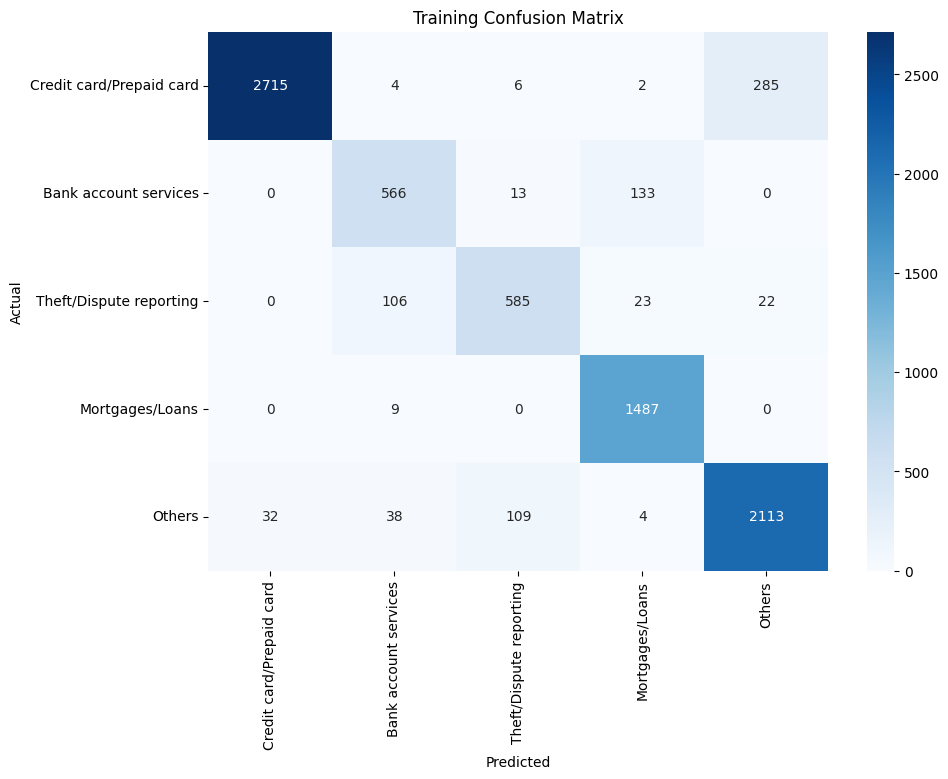


Testing Metrics:
Accuracy: 0.8826 | Precision: 0.8865 | F1: 0.8831 | ROC AUC: 0.9805
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9802    0.8949    0.9356       942
   Bank account services     0.7000    0.7568    0.7273       222
 Theft/Dispute reporting     0.7830    0.7217    0.7511       230
         Mortgages/Loans     0.8878    0.9808    0.9320       468
                  Others     0.8535    0.8928    0.8727       718

                accuracy                         0.8826      2580
               macro avg     0.8409    0.8494    0.8437      2580
            weighted avg     0.8865    0.8826    0.8831      2580


Testing Prediction Summary:
Total tickets: 2580
Correct predictions: 2277
Incorrect predictions: 303

Testing Confidence Threshold Analysis:
----------------------------------------------------------------------------------------------------
Threshold   Below       Above       Correct Below     Wrong Below     % Er

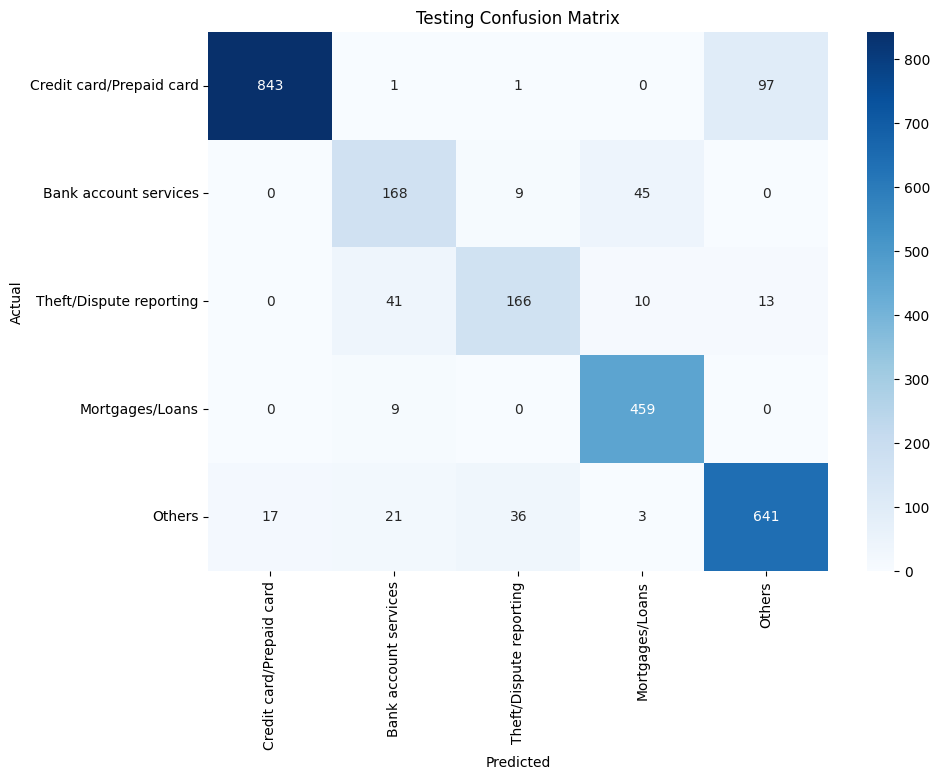


=== Fold 2/5 ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.5067
Epoch completed in 190.56 seconds

Epoch 2/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3811
Epoch completed in 190.45 seconds

Epoch 3/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3321
Epoch completed in 190.28 seconds

Fold 2 completed in 9.55 minutes

Training Metrics:
Accuracy: 0.9067 | Precision: 0.9106 | F1: 0.9074 | ROC AUC: 0.9853
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9927    0.8997    0.9439      3012
   Bank account services     0.7929    0.8118    0.8022       712
 Theft/Dispute reporting     0.7992    0.8220    0.8104       736
         Mortgages/Loans     0.9168    0.9873    0.9508      1496
                  Others     0.8710    0.9199    0.8948      2297

                accuracy                         0.9067      8253
               macro avg     0.8745    0.8881    0.8804      8253
            weighted avg     0.9106    0.9067    0.9074      8253


Training Prediction Summary:
Total tickets: 8253
Correct predictions: 7483
Incorrect predictions: 770

Training Confidence Threshold Analysis:
-----------------------------------------------------------------------------------

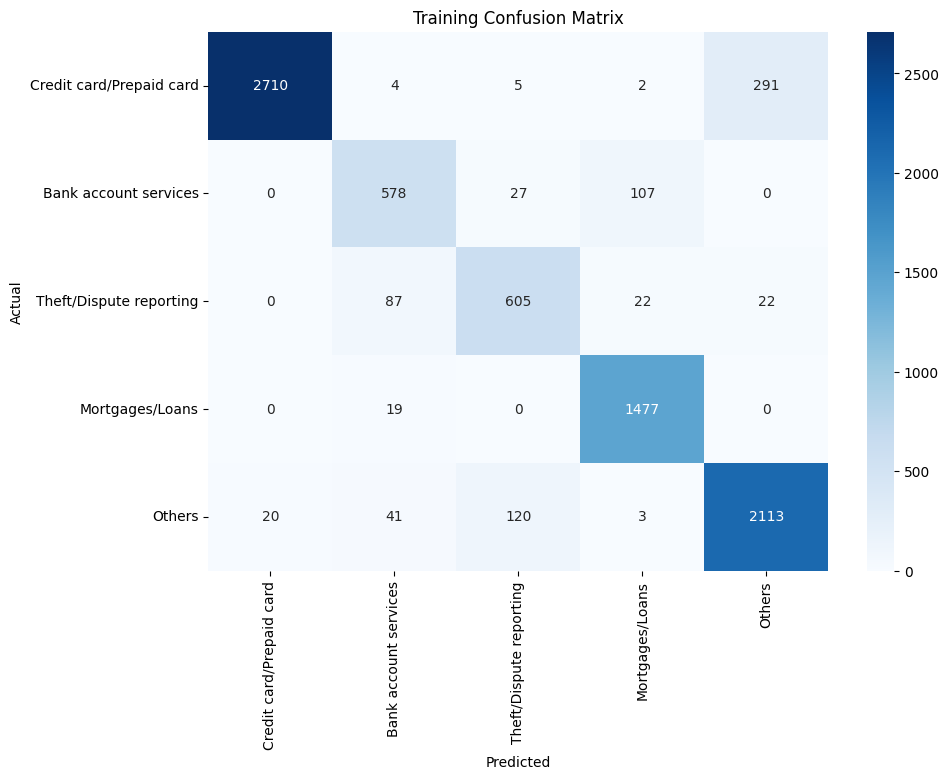


Testing Metrics:
Accuracy: 0.8903 | Precision: 0.8956 | F1: 0.8917 | ROC AUC: 0.9812
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9836    0.8928    0.9360       942
   Bank account services     0.7269    0.8153    0.7686       222
 Theft/Dispute reporting     0.7597    0.7696    0.7646       230
         Mortgages/Loans     0.9300    0.9658    0.9476       468
                  Others     0.8534    0.8997    0.8759       718

                accuracy                         0.8903      2580
               macro avg     0.8507    0.8686    0.8585      2580
            weighted avg     0.8956    0.8903    0.8917      2580


Testing Prediction Summary:
Total tickets: 2580
Correct predictions: 2297
Incorrect predictions: 283

Testing Confidence Threshold Analysis:
----------------------------------------------------------------------------------------------------
Threshold   Below       Above       Correct Below     Wrong Below     % Er

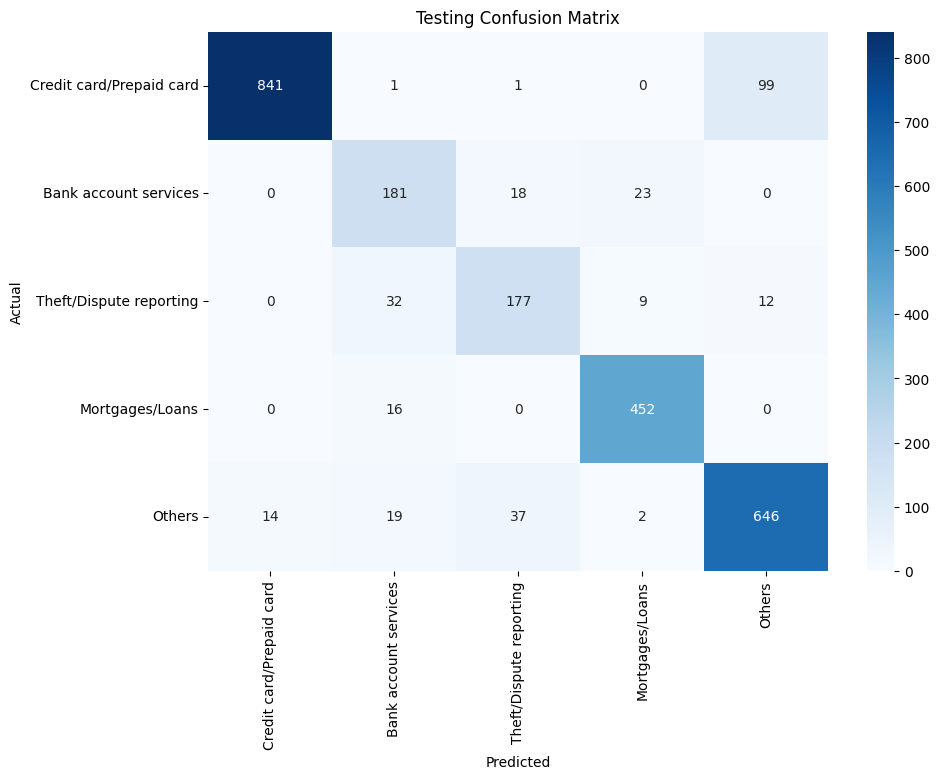


=== Fold 3/5 ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.5251
Epoch completed in 190.35 seconds

Epoch 2/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3618
Epoch completed in 189.51 seconds

Epoch 3/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3269
Epoch completed in 188.86 seconds

Fold 3 completed in 9.51 minutes

Training Metrics:
Accuracy: 0.9077 | Precision: 0.9118 | F1: 0.9085 | ROC AUC: 0.9856
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9930    0.9001    0.9443      3012
   Bank account services     0.7870    0.8301    0.8079       712
 Theft/Dispute reporting     0.7945    0.8247    0.8093       736
         Mortgages/Loans     0.9239    0.9900    0.9558      1496
                  Others     0.8736    0.9147    0.8937      2297

                accuracy                         0.9077      8253
               macro avg     0.8744    0.8919    0.8822      8253
            weighted avg     0.9118    0.9077    0.9085      8253


Training Prediction Summary:
Total tickets: 8253
Correct predictions: 7491
Incorrect predictions: 762

Training Confidence Threshold Analysis:
-----------------------------------------------------------------------------------

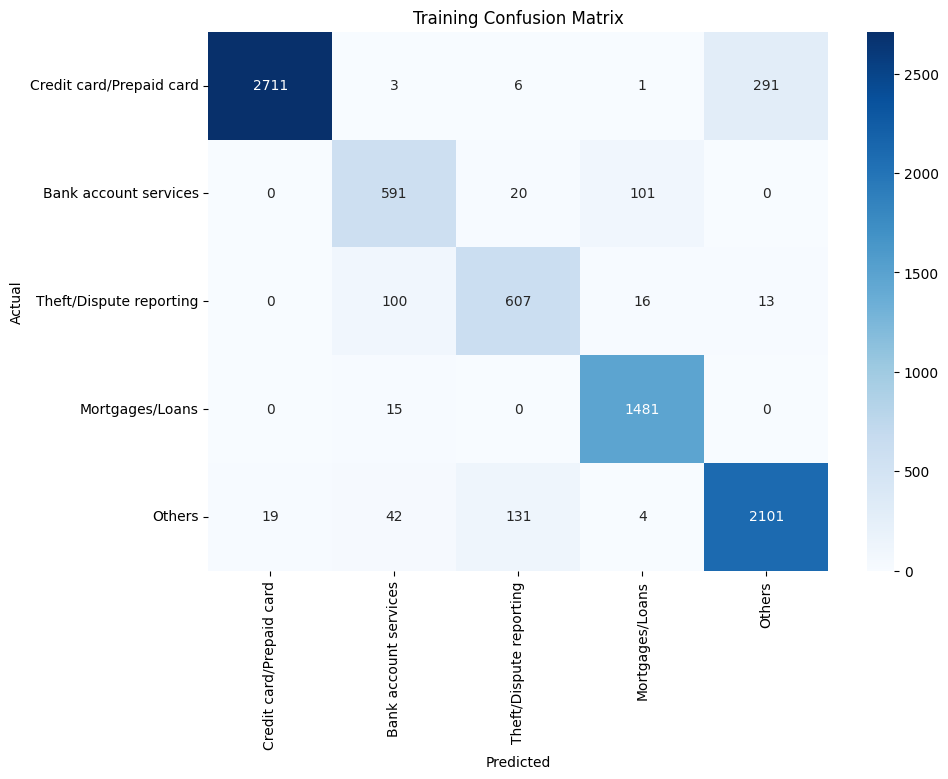


Testing Metrics:
Accuracy: 0.8888 | Precision: 0.8947 | F1: 0.8904 | ROC AUC: 0.9814
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9859    0.8938    0.9376       942
   Bank account services     0.7121    0.8243    0.7641       222
 Theft/Dispute reporting     0.7511    0.7609    0.7559       230
         Mortgages/Loans     0.9264    0.9679    0.9467       468
                  Others     0.8568    0.8914    0.8737       718

                accuracy                         0.8888      2580
               macro avg     0.8464    0.8677    0.8556      2580
            weighted avg     0.8947    0.8888    0.8904      2580


Testing Prediction Summary:
Total tickets: 2580
Correct predictions: 2293
Incorrect predictions: 287

Testing Confidence Threshold Analysis:
----------------------------------------------------------------------------------------------------
Threshold   Below       Above       Correct Below     Wrong Below     % Er

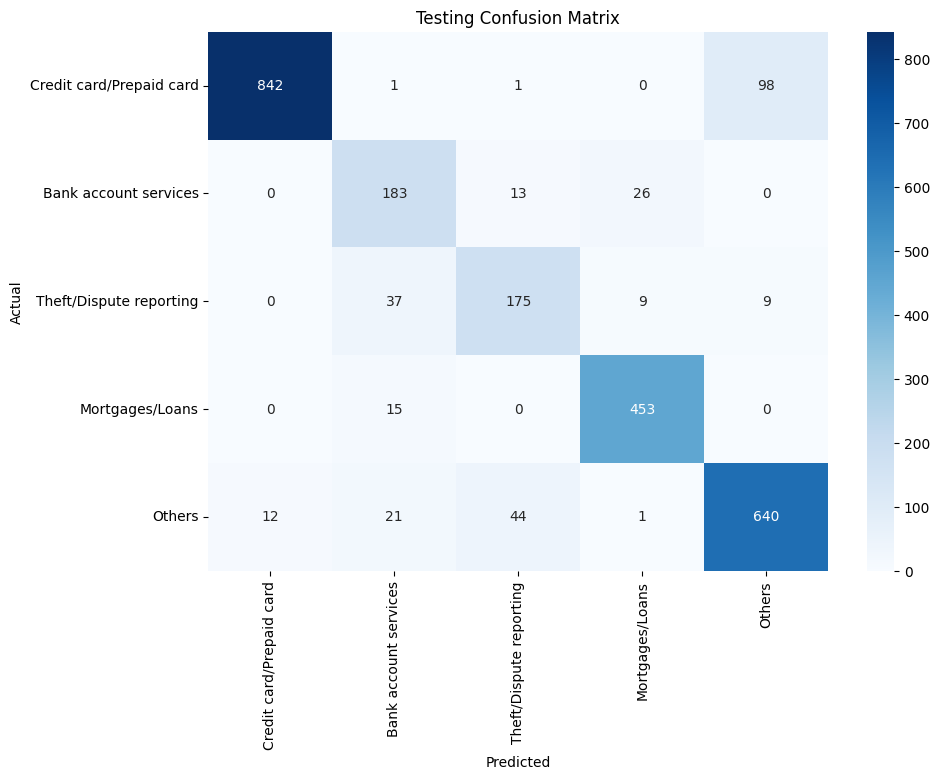


=== Fold 4/5 ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.5228
Epoch completed in 188.83 seconds

Epoch 2/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3722
Epoch completed in 188.82 seconds

Epoch 3/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3314
Epoch completed in 188.76 seconds

Fold 4 completed in 9.47 minutes

Training Metrics:
Accuracy: 0.9057 | Precision: 0.9094 | F1: 0.9064 | ROC AUC: 0.9855
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9876    0.8991    0.9413      3012
   Bank account services     0.7896    0.8329    0.8107       712
 Theft/Dispute reporting     0.8041    0.8030    0.8035       736
         Mortgages/Loans     0.9275    0.9833    0.9546      1496
                  Others     0.8659    0.9195    0.8919      2297

                accuracy                         0.9057      8253
               macro avg     0.8749    0.8875    0.8804      8253
            weighted avg     0.9094    0.9057    0.9064      8253


Training Prediction Summary:
Total tickets: 8253
Correct predictions: 7475
Incorrect predictions: 778

Training Confidence Threshold Analysis:
-----------------------------------------------------------------------------------

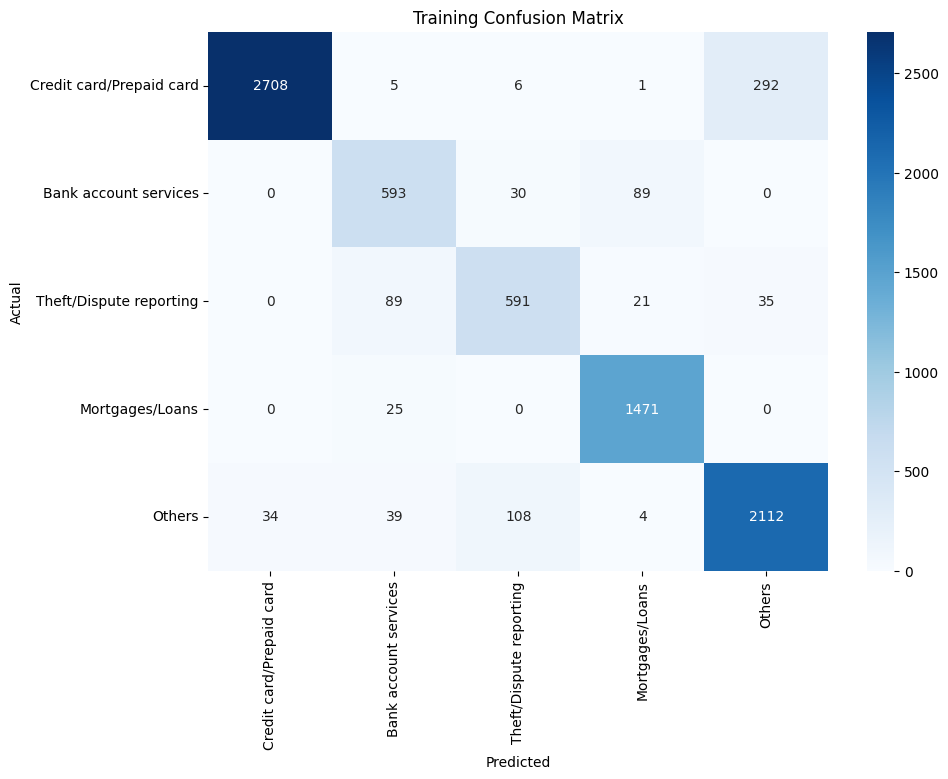


Testing Metrics:
Accuracy: 0.8853 | Precision: 0.8900 | F1: 0.8865 | ROC AUC: 0.9809
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9802    0.8949    0.9356       942
   Bank account services     0.7045    0.7838    0.7420       222
 Theft/Dispute reporting     0.7623    0.7391    0.7506       230
         Mortgages/Loans     0.9221    0.9615    0.9414       468
                  Others     0.8491    0.9011    0.8743       718

                accuracy                         0.8853      2580
               macro avg     0.8436    0.8561    0.8488      2580
            weighted avg     0.8900    0.8853    0.8865      2580


Testing Prediction Summary:
Total tickets: 2580
Correct predictions: 2284
Incorrect predictions: 296

Testing Confidence Threshold Analysis:
----------------------------------------------------------------------------------------------------
Threshold   Below       Above       Correct Below     Wrong Below     % Er

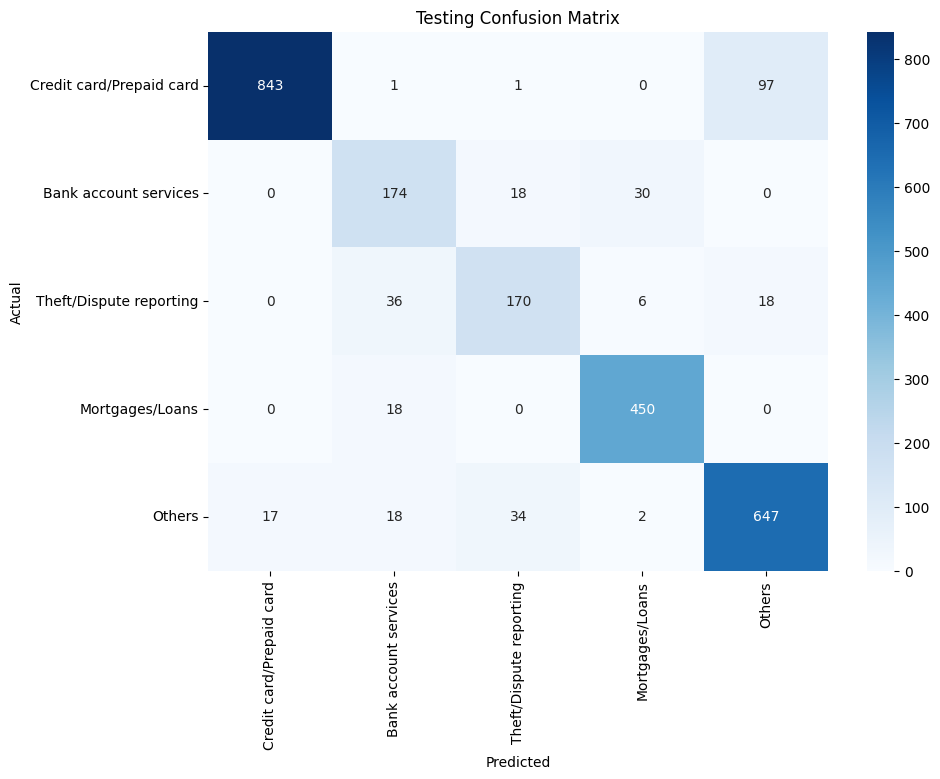


=== Fold 5/5 ===


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.5031
Epoch completed in 189.16 seconds

Epoch 2/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3697
Epoch completed in 190.55 seconds

Epoch 3/3


  0%|          | 0/1032 [00:00<?, ?it/s]

Average Loss: 0.3254
Epoch completed in 190.37 seconds

Fold 5 completed in 9.54 minutes

Training Metrics:
Accuracy: 0.9000 | Precision: 0.9053 | F1: 0.9010 | ROC AUC: 0.9838
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9963    0.8934    0.9421      3012
   Bank account services     0.7475    0.8357    0.7891       712
 Theft/Dispute reporting     0.7853    0.7704    0.7778       736
         Mortgages/Loans     0.9132    0.9846    0.9476      1496
                  Others     0.8682    0.9151    0.8911      2297

                accuracy                         0.9000      8253
               macro avg     0.8621    0.8798    0.8695      8253
            weighted avg     0.9053    0.9000    0.9010      8253


Training Prediction Summary:
Total tickets: 8253
Correct predictions: 7428
Incorrect predictions: 825

Training Confidence Threshold Analysis:
-----------------------------------------------------------------------------------

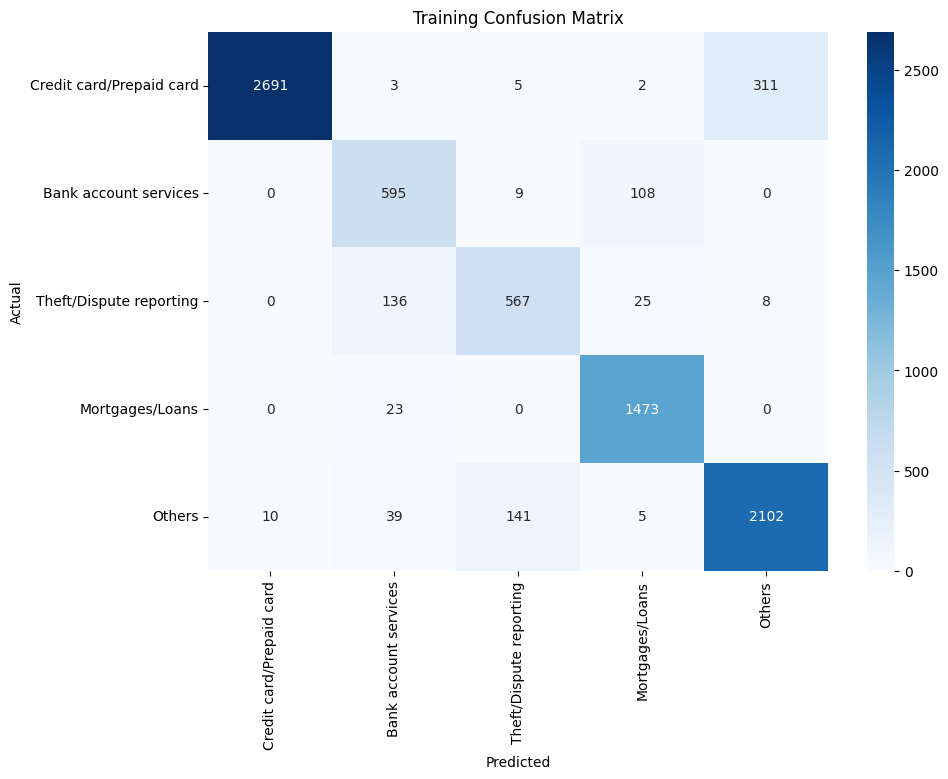


Testing Metrics:
Accuracy: 0.8818 | Precision: 0.8898 | F1: 0.8835 | ROC AUC: 0.9800
                          precision    recall  f1-score   support

Credit card/Prepaid card     0.9917    0.8832    0.9343       942
   Bank account services     0.6703    0.8243    0.7394       222
 Theft/Dispute reporting     0.7664    0.7130    0.7387       230
         Mortgages/Loans     0.9115    0.9679    0.9389       468
                  Others     0.8494    0.8955    0.8719       718

                accuracy                         0.8818      2580
               macro avg     0.8378    0.8568    0.8446      2580
            weighted avg     0.8898    0.8818    0.8835      2580


Testing Prediction Summary:
Total tickets: 2580
Correct predictions: 2275
Incorrect predictions: 305

Testing Confidence Threshold Analysis:
----------------------------------------------------------------------------------------------------
Threshold   Below       Above       Correct Below     Wrong Below     % Er

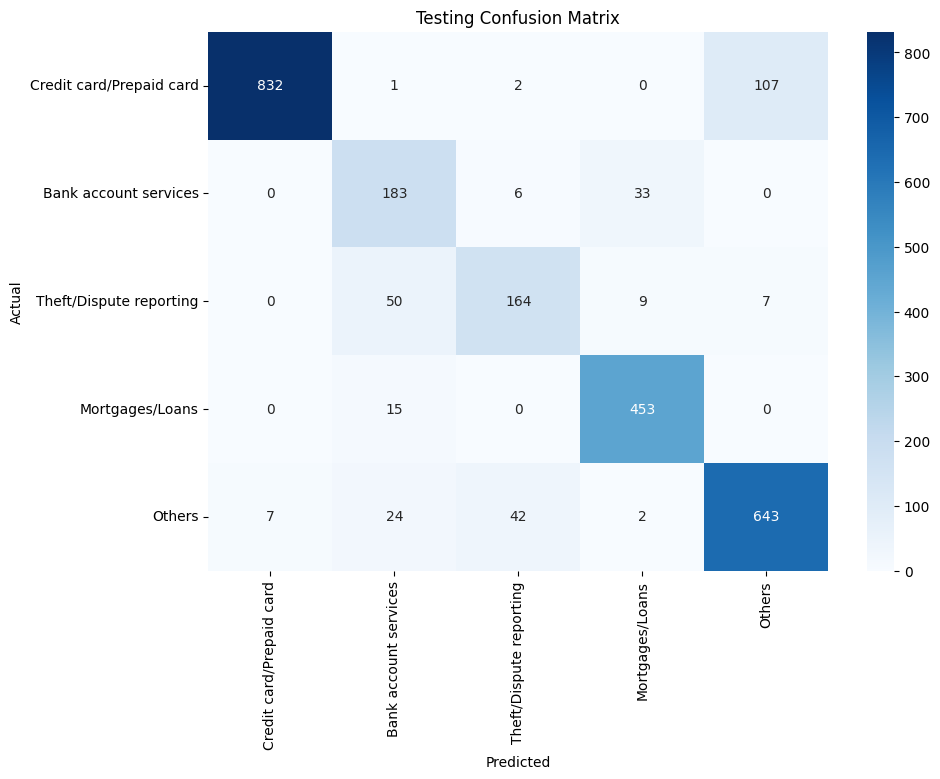


=== Training Time Summary ===
Total training time: 54.28 minutes
Average per fold: 9.51 minutes

=== Final 5-Fold Average Metrics ===

Training:
Accuracy: 0.9050 | Precision: 0.9090 | F1: 0.9056

Testing:
Accuracy: 0.8857 | Precision: 0.8913 | F1: 0.8870


In [ ]:
# ============================================================
# Cell 8: Run DeBERTa
# ============================================================

deberta_results = train_model(
    texts_train=texts_train,
    labels_train=labels_train,
    test_loader=test_loader,
    tokenizer=tokenizer,
    label_map=label_map,
    model_name=MODEL_NAME,
    max_len=MAX_LEN,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
)

In [ ]:
# ============================================================
# Cell 9: Result Summary
# ============================================================

results_df = pd.DataFrame([
    {
        "Model": deberta_results["model"],

        "Train Accuracy":
            deberta_results[
                "train"
            ]["accuracy"],

        "Train Precision":
            deberta_results[
                "train"
            ]["precision"],

        "Train F1":
            deberta_results[
                "train"
            ]["f1"],

        "Test Accuracy":
            deberta_results[
                "test"
            ]["accuracy"],

        "Test Precision":
            deberta_results[
                "test"
            ]["precision"],

        "Test F1":
            deberta_results[
                "test"
            ]["f1"],

        "Test ROC AUC":
            deberta_results[
                "test"
            ]["roc_auc"],

        "Total Time (min)":
            deberta_results[
                "total_time"
            ] / 60
    }
])

display(results_df)

,Model,Train Accuracy,Train Precision,Train F1,Test Accuracy,Test Precision,Test F1,Test ROC AUC,Total Time (min)
0,microsoft/deberta-v3-base,0.904832,0.909125,0.905601,0.889922,0.895954,0.891296,0.981308,53.917908


In [ ]:
# ============================================================
# Cell 10: Save Trained DeBERTa Model
# ============================================================

SAVE_PATH = (
    "/content/deberta_ticket_classifier"
)

final_model = (
    deberta_results["final_model"]
)

final_model.save_pretrained(
    SAVE_PATH
)

tokenizer.save_pretrained(
    SAVE_PATH
)

print(
    "Model saved to:",
    SAVE_PATH
)

Model saved to: /content/deberta_ticket_classifier
